# Autoencoder II: Loading a pre-trained model

## General configuration

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

import xarray as xr
import matplotlib.pyplot as plt

In [2]:
### Configuration ###
BATCH_SIZE    = 12
LATENT_DIM    = 2
RANDOM_SEED   = 43
FNAME_MODEL   = 'autoencoder.pt'

## Load trained model

In [3]:
from helper import Autoencoder

### Recreate the model
model = Autoencoder(LATENT_DIM)

In [5]:
# Load model for inference
model.load_state_dict(torch.load(FNAME_MODEL))
model.eval()

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=13312, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=13312, bias=True)
    (1): ReLU(inplace=True)
    (2): Unflatten(dim=1, unflattened_size=(64, 13, 16))
    (3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 0))
    (4): ReLU(inplace=True)
    (5): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): ReLU(inplace=True)
  )
)

## Load validation dataset

In [6]:
from helper import EnsembleDataset
from helper import MinMaxScale

fname = 'data/tephra_col_mass.nc'
ds = xr.open_dataset(fname)
da = ds["tephra_col_mass"]

transform = MinMaxScale(0, 25)
dataset = EnsembleDataset(da, transform)

# Random split with in training and validation datasets
n_total = len(dataset)
n_train = int(0.8 * n_total)   # 80% train
n_val   = n_total - n_train    # 20% val

torch.manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

## State reconstruction

In [7]:
xp_list = []
xv_list = []
with torch.no_grad():
    for batch in val_loader:
        prediction = model(batch)
        xp = prediction.squeeze(1)
        xv = batch.squeeze(1)
        xp_list.append(transform.invert(xp))
        xv_list.append(transform.invert(xv))
    xp = torch.cat(xp_list, dim=0)
    xv = torch.cat(xv_list, dim=0)

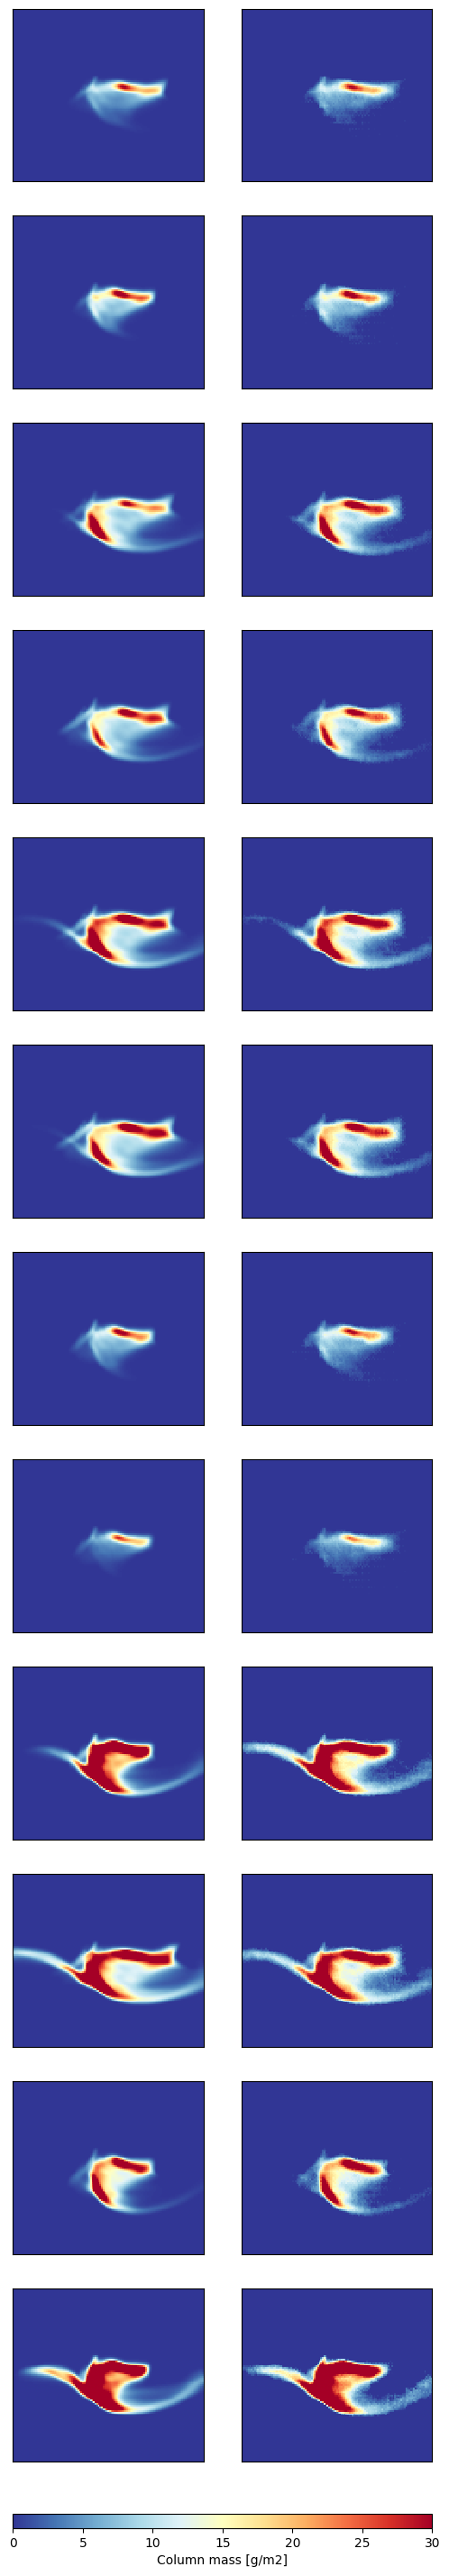

In [8]:
## Plotting reconstructions for validation dataset 
plot_conf = {
    'cmap': 'RdYlBu_r',
    'vmin': 0, 
    'vmax': 30,
}

n=min(12,n_val)
fig, axs = plt.subplots(nrows = n, ncols = 2, figsize=(6,38))

for i in range(n):
    cs1=axs[i,0].pcolormesh(da.lon,da.lat,xv[i], **plot_conf)
    cs2=axs[i,1].pcolormesh(da.lon,da.lat,xp[i], **plot_conf)
                        
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    
cbar = fig.colorbar(cs2, 
             ax=axs, 
             orientation='horizontal',
             fraction=0.05,
             pad=0.02, 
             aspect=30
            )
cbar.set_label('Column mass [g/m2]')

## Latent Space Visualization

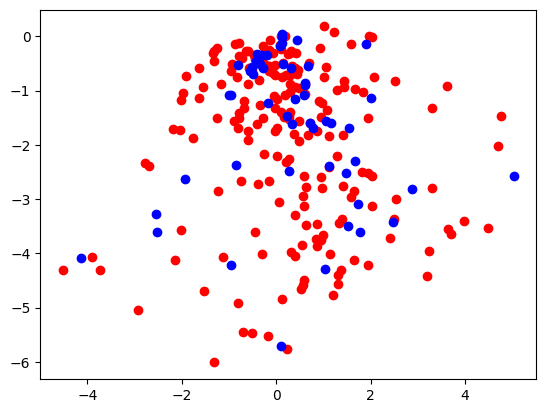

In [9]:
fig, ax = plt.subplots()

with torch.no_grad():
    for batch in train_loader:
        z = model.encode(batch)
        ax.scatter(z[:,0],z[:,1], color='red')
    for batch in val_loader:
        z = model.encode(batch)
        ax.scatter(z[:,0],z[:,1], color='blue')

## Generating new samples

In [10]:
z = torch.tensor([[4,-2]], dtype=torch.float32)
with torch.no_grad():
    new_sample = model.decode(z)
    x = transform.invert(new_sample).squeeze()

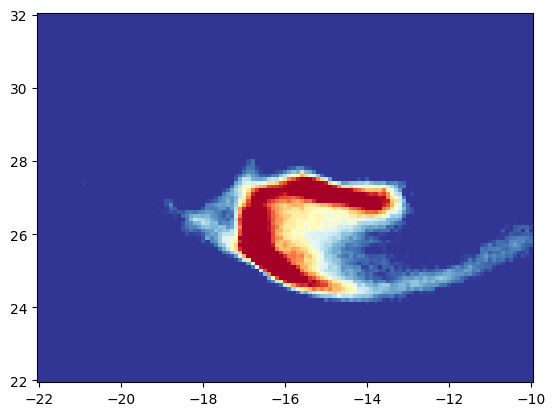

In [11]:
fig, ax = plt.subplots()
ax.pcolormesh(da.lon,da.lat,x,**plot_conf)